# FMNIST

- load FMNIST dataset (Fashion MNIST)
- split dataset into train/dev/test
- design CNN to classify FMNIST dataset features
- show loss / accuracy over epochs
- try to beat:
    - dev/test accuracy: ~90% / ~90% @ most 10 epochs
    - train/dev loss: ~0.4 / ~0.3 @ most 10 epochs

In [1]:
# import libraries
import numpy as np

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,TensorDataset,Subset

# for getting summary info on models
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import and inspect data

In [3]:
# download the dataset
transform = transforms.Compose([ transforms.ToTensor(),
                                 transforms.Normalize(.5,.5),
                               ])

fmnist_train = torchvision.datasets.FashionMNIST(root='../sample_data/fmnist',download=True,train=True,transform=transform)
fmnist_test = torchvision.datasets.FashionMNIST(root='../sample_data/fmnist',download=True,train=False,transform=transform)

print(fmnist_train)
print(fmnist_test)

print(fmnist_train.class_to_idx)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../sample_data/fmnist
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../sample_data/fmnist
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


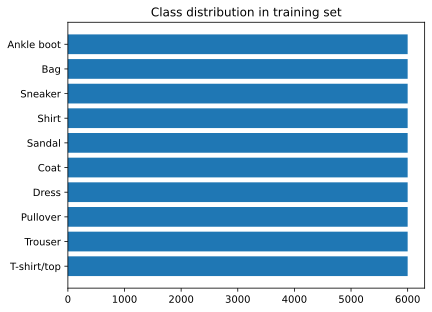

In [4]:
# Show classe/counts statistics
unique, counts = np.unique(fmnist_train.targets, return_counts=True)

plt.figure()
plt.barh([fmnist_train.classes[ci] for ci in unique], counts)
plt.title('Class distribution in training set')
plt.show()

In [16]:
# Cerate train/dev/test splits:

randidx = np.random.permutation(fmnist_test.data.shape[0])   # a random permutation of indices
split_idx = int(0.5 * len(randidx))               # split index at 50%
devset  = Subset(fmnist_test,randidx[:split_idx]) # Subset for devset
testset = Subset(fmnist_test,randidx[split_idx:]) # Subset for test

# transform to dataloaders
batchsize    = 500
train_loader = DataLoader(fmnist_train,batch_size=batchsize,shuffle=True,drop_last=True)
dev_loader   = DataLoader(devset,  batch_size=len(devset))
test_loader  = DataLoader(testset, batch_size=len(testset))

# Create CNN to classify FMNIST

In [17]:
def makeTheNet(lr:float=.001,print_toggle:bool=False):
    class fmnist(nn.Module):
        def __init__(self, num_features:int=10, print_toggle:bool=False):
            super().__init__()
            self.print = print_toggle
            self.in_size = 28  # 28 x 28
            self.nfeat = num_features
            self.p2d_strd = 2 # stride for maxpool2d
            self.p_drop = .2
            
            # For equation see: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
            CNNLayerOutSize = lambda in_dim, conv, pooling: \
                int(np.ceil((in_dim + 2*conv.padding[0] - conv.kernel_size[0])//conv.stride[0] + 1)//pooling)
            
            # Convolution layers
            self.conv1 = nn.Conv2d(1,32,kernel_size=5,stride=1,padding=1)
            self.bn1 = nn.BatchNorm2d(self.conv1.out_channels)
            nOutCNNLayer1 = CNNLayerOutSize(self.in_size, self.conv1, self.p2d_strd)
            if self.print: print(f'nOutCNNLayer1: {nOutCNNLayer1}')
            
            self.conv2 = nn.Conv2d(self.conv1.out_channels,64,kernel_size=3,stride=1,padding=1)
            self.bn2 = nn.BatchNorm2d(self.conv2.out_channels)
            nOutCNNLayer2 = CNNLayerOutSize(nOutCNNLayer1, self.conv2, self.p2d_strd)
            if self.print: print(f'nOutCNNLayer2: {nOutCNNLayer2}')
            
            # Flat layers
            self.fc1 = nn.Linear(nOutCNNLayer2*nOutCNNLayer2*self.conv2.out_channels, 128)
            self.bn_fc1 = nn.BatchNorm1d(self.fc1.out_features)
            
            self.fc2 = nn.Linear(self.fc1.out_features, 16)
            self.bn_fc2 = nn.BatchNorm1d(self.fc2.out_features)
            
            self.fc_out = nn.Linear(self.fc2.out_features, 10)
            self.bn_fc_out = nn.BatchNorm1d(self.fc_out.out_features)

        def forward(self,x):
            # Convolution layers
            x = self.conv1(x)
            x = F.max_pool2d(x,kernel_size=self.p2d_strd)
            x = F.relu(x)
            x = self.bn1(x)
            x = F.dropout2d(x, p=self.p_drop, training=self.training)
            if self.print: print(f'\nconv1 output size: {list(x.shape)}')
            
            x = self.conv2(x)
            x = F.max_pool2d(x,kernel_size=self.p2d_strd)
            x = F.relu(x)
            x = self.bn2(x)
            x = F.dropout2d(x, p=self.p_drop, training=self.training)
            if self.print: print(f'conv2 output size: {list(x.shape)}')
            
            # Flat layers
            x = torch.flatten(x, start_dim=1)
            if self.print: print(f'flattened output size: {list(x.shape)}')

            x = self.fc1(x)
            x = self.bn_fc1(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.p_drop, training=self.training)
            if self.print: print(f'fc1 output size: {list(x.shape)}')
            
            x = self.fc2(x)
            x = self.bn_fc2(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.p_drop, training=self.training)
            if self.print: print(f'fc2 output size: {list(x.shape)}')

            x = self.fc_out(x)
            if self.print: print(f'fc_out output size: {list(x.shape)}\n')

            return x
        
        @staticmethod
        def accuracy(yHat,y):
            return (torch.argmax(yHat,dim=1) == y).float().mean().item()
    
    net = fmnist(print_toggle=print_toggle)
    lossfun = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(),lr=lr)
    
    return net, lossfun, optimizer

# Try network on some data
net, lossfun, optimizer = makeTheNet(print_toggle=True)

X,y = next(iter(train_loader))
X = X[:3]
y = y[:3]
print('X.shape: ', X.shape)
print('y.shape: ', y.shape)
yHat = net(X)
print('yHat.shape: ', yHat.shape)

loss = lossfun(yHat,y)
acc = net.accuracy(yHat,y)
print('Loss:',loss.item())
print('Acc :',acc)

summary(net,X[0].shape, device='cpu')

nOutCNNLayer1: 13
nOutCNNLayer2: 6
X.shape:  torch.Size([3, 1, 28, 28])
y.shape:  torch.Size([3])

conv1 output size: [3, 32, 13, 13]
conv2 output size: [3, 64, 6, 6]
flattened output size: [3, 2304]
fc1 output size: [3, 128]
fc2 output size: [3, 16]
fc_out output size: [3, 10]

yHat.shape:  torch.Size([3, 10])
Loss: 2.319973945617676
Acc : 0.0

conv1 output size: [2, 32, 13, 13]
conv2 output size: [2, 64, 6, 6]
flattened output size: [2, 2304]
fc1 output size: [2, 128]
fc2 output size: [2, 16]
fc_out output size: [2, 10]

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             832
       BatchNorm2d-2           [-1, 32, 13, 13]              64
            Conv2d-3           [-1, 64, 13, 13]          18,496
       BatchNorm2d-4             [-1, 64, 6, 6]             128
            Linear-5                  [-1, 128]         295,040
       BatchNorm1d-6  

# Train the Model

In [18]:
# a function that trains the model
def function2trainTheModel(train_loader, dev_loader, lr, numepochs:int=3):

  # create a new model
  net,lossfun,optimizer = makeTheNet(lr=lr)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  devLoss  = torch.zeros(numepochs)
  trainAcc  = torch.zeros(numepochs)
  devAcc   = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):
    net.train()

    # loop over training data batches
    batchLoss = []
    batchAcc  = []
    
    for batchi,(X,y) in enumerate(train_loader):

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchAcc.append(net.accuracy(yHat,y))
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi]  = 100*np.mean(batchAcc)

    ### dev performance
    net.eval()
    X,y = next(iter(dev_loader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
    devLoss[epochi] = loss.item()
    devAcc[epochi] = 100*net.accuracy(yHat,y)

    print(f'epoch {epochi+1}/{numepochs}: '
          f'train loss: {trainLoss[epochi]:.4f} '
          f'dev loss: {devLoss[epochi]:.4f} '
          f'train acc: {trainAcc[epochi]:.2f}% '
          f'dev acc: {devAcc[epochi]:.2f}%', end='\r' )

  # end epochs
  
  net.eval() # set model to eval mode as done training

  # function output
  return trainLoss,devLoss,trainAcc,devAcc,net

In [19]:
trainLoss,devLoss,trainAcc,devAcc,net = function2trainTheModel(
    train_loader, dev_loader, lr=.001, numepochs=10)

In [20]:
# Run on test_set
X_test,y_test = next(iter(test_loader))
X_test = X_test.to(device)
y_test = y_test.to(device)

with torch.no_grad():
    yHat_test = net(X_test).cpu().detach()
X_test = X_test.cpu().detach().to(torch.float32)
y_test = y_test.cpu().detach()

testLoss = lossfun(yHat_test,y_test).item()
testAcc  = 100*net.accuracy(yHat_test,y_test)

print('testLoss:', testLoss)
print('testAcc:', testAcc)

testLoss: 0.22871264815330505
testAcc: 92.14000105857849


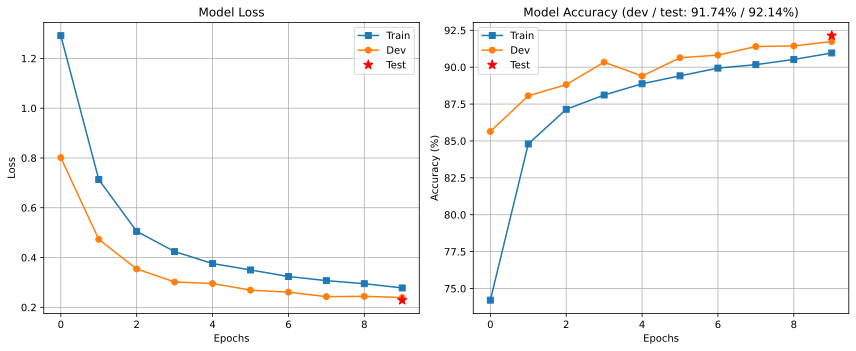

In [21]:
fig,axs = plt.subplots(1,2,figsize=(12,5))

axs[0].plot(trainLoss,'s-',label='Train')
axs[0].plot(devLoss,'o-',label='Dev')
axs[0].plot(len(trainLoss)-1, testLoss,'r*',markersize=10, label='Test')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Model Loss')

axs[1].plot(trainAcc,'s-',label='Train')
axs[1].plot(devAcc,'o-',label='Dev')
axs[1].plot(len(trainAcc)-1, testAcc,'r*',markersize=10, label='Test')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title(f'Model Accuracy (dev / test: {devAcc[-1]:.2f}% / {testAcc:.2f}%)')

for a in axs.flatten():
    a.grid(True)
    a.legend()
    a.set_xlabel('Epochs')

fig.tight_layout()
plt.show()

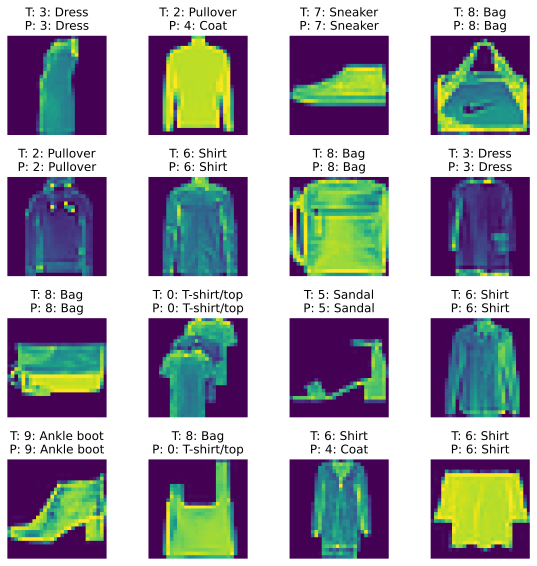

In [22]:
# Show some sample images
fig = plt.figure(figsize=(8,8))

random_indexes = np.random.choice(X_test.shape[0], 16, replace=False)
for idx, i in enumerate(random_indexes):
    ax = fig.add_subplot(4,4,idx+1)
    ax.imshow(X_test[i].cpu().numpy().transpose(1, 2, 0))  # transpose to HWC for display
    ax.set_title(f'T: {y_test[i].item()}: {fmnist_train.classes[y_test[i].item()]}\n'
                 f'P: {torch.argmax(yHat_test[i]).item()}: {fmnist_train.classes[torch.argmax(yHat_test[i]).item()]}')
    ax.axis('off')
fig.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

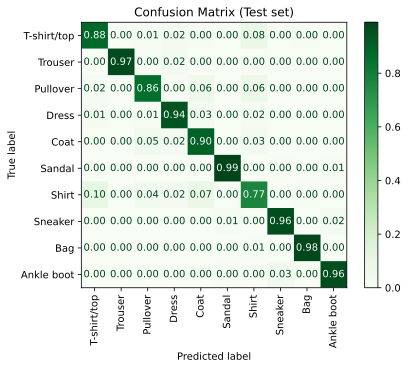

In [23]:
# Show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(10,10))
cm_display = ConfusionMatrixDisplay.from_predictions(y_test.cpu().numpy(), torch.argmax(yHat_test,axis=1).cpu().numpy(),
                                                    display_labels=[fmnist_train.classes[i] for i in range(10)],
                                                    cmap=plt.cm.Greens,
                                                    xticks_rotation='vertical',
                                                    values_format='.2f',
                                                    normalize='true')
cm_display.ax_.set_title('Confusion Matrix (Test set)')

fig.tight_layout()
plt.show()